In [6]:
import xgboost
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import statistics


In [7]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [8]:
data = pd.read_csv('../Data/preprocessed/NP15_rt_series.csv')
data['begin_time'] = pd.to_datetime(data['begin_time'])
data_15min = data[data['begin_time'].apply(lambda x : x.minute%15 == 0)].copy()
data_15min

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price
0,2021-01-01 00:00:00,30.76070,NaN,NaN
3,2021-01-01 00:15:00,31.35044,NaN,NaN
6,2021-01-01 00:30:00,32.45147,NaN,NaN
9,2021-01-01 00:45:00,29.98897,NaN,NaN
12,2021-01-01 01:00:00,29.89887,NaN,NaN
...,...,...,...,...
420753,2024-12-31 22:45:00,45.92347,6.20218,39.72129
420756,2024-12-31 23:00:00,46.50217,8.26084,38.24133
420759,2024-12-31 23:15:00,46.25834,7.86632,38.39202
420762,2024-12-31 23:30:00,45.51538,9.08338,36.43200


In [9]:
exog = pd.read_csv('../Data/preprocessed/NP15_exog.csv')
exog['begin_time'] = pd.to_datetime(exog['begin_time'])
exog

,begin_time,load_actual,load_forecast,solar_forecast,wind_forecast,solar_actual,wind_actual,nat_gas_price,da_price,weekday,hour,load_diffs,load_diffs_prevtime,solar_diffs,solar_diffs_prevtime,wind_diffs,wind_diffs_prevtime,load_prevtime,solar_prevtime,wind_prevtime
0,2021-03-12 00:00:00,9914.0,10102.7200,0.0,327.9700,-2.69832,526.78168,2.65,42.965480,1,0,-188.7200,NaN,-2.69832,NaN,198.81168,NaN,NaN,NaN,NaN
1,2021-03-12 00:15:00,9914.0,10044.1825,0.0,310.9625,-2.69832,526.78168,2.65,42.096353,1,0,-130.1825,-188.7200,-2.69832,-2.69832,215.81918,198.81168,9914.0,-2.69832,526.78168
2,2021-03-12 00:30:00,9914.0,9985.6450,0.0,293.9550,-2.69832,526.78168,2.65,41.227225,1,0,-71.6450,-130.1825,-2.69832,-2.69832,232.82668,215.81918,9914.0,-2.69832,526.78168
3,2021-03-12 00:45:00,9914.0,9927.1075,0.0,276.9475,-2.69832,526.78168,2.65,40.358097,1,0,-13.1075,-71.6450,-2.69832,-2.69832,249.83418,232.82668,9914.0,-2.69832,526.78168
4,2021-03-12 01:00:00,9827.0,9868.5700,0.0,259.9400,-2.66009,405.97186,2.65,39.488970,1,1,-41.5700,-13.1075,-2.66009,-2.69832,146.03186,249.83418,9914.0,-2.69832,526.78168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133528,2024-12-31 22:00:00,10226.0,10831.4600,0.0,77.4600,-6.26466,54.79276,3.40,51.551140,1,22,-605.4600,-361.7950,-6.26466,-6.79170,-22.66724,-11.79188,10614.0,-6.79170,62.77812
133529,2024-12-31 22:15:00,10226.0,10682.2425,0.0,80.2975,-6.26466,54.79276,3.40,51.422337,1,22,-456.2425,-605.4600,-6.26466,-6.26466,-25.50474,-22.66724,10226.0,-6.26466,54.79276
133530,2024-12-31 22:30:00,10226.0,10533.0250,0.0,83.1350,-6.26466,54.79276,3.40,51.293535,1,22,-307.0250,-456.2425,-6.26466,-6.26466,-28.34224,-25.50474,10226.0,-6.26466,54.79276
133531,2024-12-31 22:45:00,10226.0,10383.8075,0.0,85.9725,-6.26466,54.79276,3.40,51.164732,1,22,-157.8075,-307.0250,-6.26466,-6.26466,-31.17974,-28.34224,10226.0,-6.26466,54.79276


In [10]:
data_comb = pd.merge(data_15min, exog, how='inner', on='begin_time')
data_comb

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price,load_actual,load_forecast,solar_forecast,wind_forecast,solar_actual,wind_actual,...,hour,load_diffs,load_diffs_prevtime,solar_diffs,solar_diffs_prevtime,wind_diffs,wind_diffs_prevtime,load_prevtime,solar_prevtime,wind_prevtime
0,2021-03-12 00:00:00,34.56084,-21.12893,55.68977,9914.0,10102.7200,0.0,327.9700,-2.69832,526.78168,...,0,-188.7200,NaN,-2.69832,NaN,198.81168,NaN,NaN,NaN,NaN
1,2021-03-12 00:15:00,35.35549,-25.15432,60.50981,9914.0,10044.1825,0.0,310.9625,-2.69832,526.78168,...,0,-130.1825,-188.7200,-2.69832,-2.69832,215.81918,198.81168,9914.0,-2.69832,526.78168
2,2021-03-12 00:30:00,34.51972,-22.99046,57.51018,9914.0,9985.6450,0.0,293.9550,-2.69832,526.78168,...,0,-71.6450,-130.1825,-2.69832,-2.69832,232.82668,215.81918,9914.0,-2.69832,526.78168
3,2021-03-12 00:45:00,32.77203,-14.96161,47.73364,9914.0,9927.1075,0.0,276.9475,-2.69832,526.78168,...,0,-13.1075,-71.6450,-2.69832,-2.69832,249.83418,232.82668,9914.0,-2.69832,526.78168
4,2021-03-12 01:00:00,33.10504,-18.19313,51.29817,9827.0,9868.5700,0.0,259.9400,-2.66009,405.97186,...,1,-41.5700,-13.1075,-2.66009,-2.69832,146.03186,249.83418,9914.0,-2.69832,526.78168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133528,2024-12-31 22:00:00,46.56593,2.44625,44.11968,10226.0,10831.4600,0.0,77.4600,-6.26466,54.79276,...,22,-605.4600,-361.7950,-6.26466,-6.79170,-22.66724,-11.79188,10614.0,-6.79170,62.77812
133529,2024-12-31 22:15:00,46.33350,2.58961,43.74389,10226.0,10682.2425,0.0,80.2975,-6.26466,54.79276,...,22,-456.2425,-605.4600,-6.26466,-6.26466,-25.50474,-22.66724,10226.0,-6.26466,54.79276
133530,2024-12-31 22:30:00,47.24685,4.88912,42.35773,10226.0,10533.0250,0.0,83.1350,-6.26466,54.79276,...,22,-307.0250,-456.2425,-6.26466,-6.26466,-28.34224,-25.50474,10226.0,-6.26466,54.79276
133531,2024-12-31 22:45:00,45.92347,6.20218,39.72129,10226.0,10383.8075,0.0,85.9725,-6.26466,54.79276,...,22,-157.8075,-307.0250,-6.26466,-6.26466,-31.17974,-28.34224,10226.0,-6.26466,54.79276


In [11]:
data_train=data_comb.iloc[:106826]
data_train = data_train.dropna()
data_train

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price,load_actual,load_forecast,solar_forecast,wind_forecast,solar_actual,wind_actual,...,hour,load_diffs,load_diffs_prevtime,solar_diffs,solar_diffs_prevtime,wind_diffs,wind_diffs_prevtime,load_prevtime,solar_prevtime,wind_prevtime
1,2021-03-12 00:15:00,35.35549,-25.15432,60.50981,9914.0,10044.1825,0.0000,310.9625,-2.69832,526.78168,...,0,-130.1825,-188.7200,-2.69832,-2.69832,215.81918,198.81168,9914.0,-2.69832,526.78168
2,2021-03-12 00:30:00,34.51972,-22.99046,57.51018,9914.0,9985.6450,0.0000,293.9550,-2.69832,526.78168,...,0,-71.6450,-130.1825,-2.69832,-2.69832,232.82668,215.81918,9914.0,-2.69832,526.78168
3,2021-03-12 00:45:00,32.77203,-14.96161,47.73364,9914.0,9927.1075,0.0000,276.9475,-2.69832,526.78168,...,0,-13.1075,-71.6450,-2.69832,-2.69832,249.83418,232.82668,9914.0,-2.69832,526.78168
4,2021-03-12 01:00:00,33.10504,-18.19313,51.29817,9827.0,9868.5700,0.0000,259.9400,-2.66009,405.97186,...,1,-41.5700,-13.1075,-2.66009,-2.69832,146.03186,249.83418,9914.0,-2.69832,526.78168
5,2021-03-12 01:15:00,34.09058,-15.96057,50.05115,9827.0,9829.5525,0.0000,242.8150,-2.66009,405.97186,...,1,-2.5525,-41.5700,-2.66009,-2.66009,163.15686,146.03186,9827.0,-2.66009,405.97186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106821,2024-03-28 17:15:00,12.28916,-16.96537,29.25453,9959.0,9763.4775,572.4575,579.0300,454.61691,498.32691,...,17,195.5225,433.7300,-117.84059,-233.74309,-80.70309,-81.27309,9959.0,454.61691,498.32691
106822,2024-03-28 17:30:00,32.78911,5.34849,27.44062,9959.0,10001.6850,456.5550,578.4600,454.61691,498.32691,...,17,-42.6850,195.5225,-1.93809,-117.84059,-80.13309,-80.70309,9959.0,454.61691,498.32691
106823,2024-03-28 17:45:00,51.68044,4.46656,47.21388,9959.0,10239.8925,340.6525,577.8900,454.61691,498.32691,...,17,-280.8925,-42.6850,113.96441,-1.93809,-79.56309,-80.13309,9959.0,454.61691,498.32691
106824,2024-03-28 18:00:00,25.27534,4.62560,20.64974,10702.0,10478.1000,224.7500,577.3200,49.33113,534.65286,...,18,223.9000,-280.8925,-175.41887,113.96441,-42.66714,-79.56309,9959.0,454.61691,498.32691


In [12]:
xgb_reg2 = xgboost.XGBRegressor(learning_rate=1,max_depth=1,n_estimators=20)

X = data_train[['nat_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime','wind_forecast', 'load_forecast', 'solar_forecast', 'da_price', 'weekday', 'hour']]
y = data_train['NP-15 LMP']

xgb_reg2.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=1,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
def crossValidateFinal(year, n_splits, test_size, n_estimators, non_seas_order, seas_order):
    ts_split = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    mse_list = []
    mse_base_list = []

    for tod in range(0, 2):
        for j in range(3,13, 3):
            time1xgb = datetime.datetime(year, j-2, 1, 0, 0, 0)
            time1ts = datetime.datetime(year, j, 14, 0, 0, 0)
            time2 = datetime.datetime(year, j, 28, (12 + (6*tod)), 0, 0)
            df = data_train[filter_times(data_train, time1xgb, time2)].copy().reset_index(drop=True)
            for i, (train_index, test_index) in enumerate(ts_split.split(df)):
                xgb_model = xgboost.XGBRegressor(learning_rate=1,max_depth=2,n_estimators=n_estimators)
                train_fold = df.loc[train_index].dropna()
                X_train = train_fold[['nat_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime','wind_forecast', 'load_forecast', 'solar_forecast', 'da_price', 'weekday', 'hour']]
                y_train = train_fold[['begin_time','NP-15 LMP']].copy()
                xgb_model.fit(X_train, y_train['NP-15 LMP'])
                y_train['xgb_fits'] = xgb_model.predict(X_train)
                y_train['xgb_resids'] = y_train['NP-15 LMP']-y_train['xgb_fits']
                #print(y_train['xgb_resids'])
                #print(y_train['xgb_resids'][filter_times(y_train, time1ts, time2)].index)
                #ts_model = SARIMAX(endog=y_train['xgb_resids'][filter_times(y_train, time1ts, time2)].reset_index(drop=True), trend='c', order=non_seas_order, seasonal_order=seas_order)
                #ts_model_fit = ts_model.fit()
                #forecast = ts_model_fit.forecast(test_size).to_frame(name='predicted')
                #print(y_train['xgb_resids'].tail(test_size))
                #print(forecast)
                test_fold = df.loc[test_index].copy()
                #forecast.index = test_fold.index
                test_fold['resid_preds'] = [y_train['xgb_resids'].iloc[-1] for _ in range(len(test_fold))]
                test_fold.dropna(inplace=True)
                X_test = test_fold[['nat_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime','wind_forecast', 'load_forecast', 'solar_forecast', 'da_price', 'weekday', 'hour']]
                y_test = test_fold['NP-15 LMP']
                xgb_preds = xgb_model.predict(X_test)
                test_fold['xgb_preds'] = xgb_preds
                test_fold['final_preds']=test_fold['xgb_preds']+test_fold['resid_preds']
                #print(test_fold['final_preds'])
                pred_baseline = [y_train['NP-15 LMP'].iloc[-1] for _ in range(len(y_test))]
                test_fold['pred_baseline'] = pred_baseline
                mse = mean_squared_error(y_test, test_fold['final_preds'])
                mse_base = mean_squared_error(y_test, pred_baseline)
                mse_list.append(mse)
                mse_base_list.append(mse_base)
                data_predicted = pd.merge(pd.concat([y_train[['begin_time', 'xgb_fits']].tail(test_size).rename(columns={'xgb_fits':'xgb_preds'}), test_fold[['begin_time', 'xgb_preds']]]), df[['begin_time', 'NP-15 LMP']], on='begin_time', how='inner')
                data_predicted = pd.merge(pd.concat([y_train[['begin_time', 'NP-15 LMP']].tail(test_size).rename(columns={'NP-15 LMP':'final_preds'}), test_fold[['begin_time', 'final_preds']]]), data_predicted, on='begin_time', how='inner')
                #data_predicted = pd.merge(pd.concat([train_fold[['begin_time', 'NP-15 LMP']].tail(test_size).rename(columns={'NP-15 LMP':'final_preds'}), test_fold[['begin_time', 'final_preds']]]), df[['begin_time', 'NP-15 LMP']], on='begin_time', how='inner')
                #print(f"mse for validation from time {df['begin_time'].loc[test_index[0]]} to {df['begin_time'].loc[test_index[-1]]} , fold {i} = {mse}. Baseline = {mse_base}")
              #print(model_fit.summary())
              #mse = mean_squared_error(df['NP-15 LMP'].loc[test_index], model_fit.forecast(test_size))
              #mse_list.append(mse)
                #data_predicted = df.join(pd.concat([train_fold.tail(test_size), model_fit.forecast(test_size, exog=df[['Natural_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime', 'solar_prevtime', 'wind_prevtime', 'load_prevtime']].loc[test_index])]).to_frame(name='predicted'), how='inner')
                plt.figure(figsize=(18, 4))
                #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP Prev_day_price'] , label='Previous day price')
                plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP'] , label='Actual price')
                plt.plot(data_predicted['begin_time'], data_predicted['xgb_preds'] , label='XGB only')
                plt.plot(data_predicted['begin_time'], data_predicted['final_preds'] , label='XGB+TS')
                plt.xticks(rotation=90)
                plt.legend()
                plt.show()
        print(f"tod {tod} done.")

    print(f"Validation error for {year} = {statistics.fmean(mse_list)}, baseline = {statistics.fmean(mse_base_list)}")

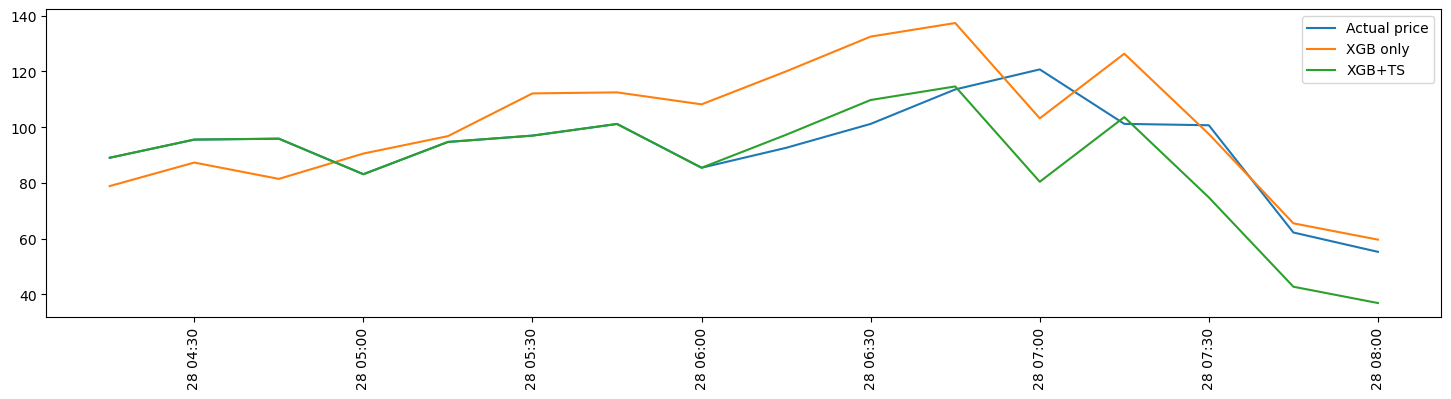

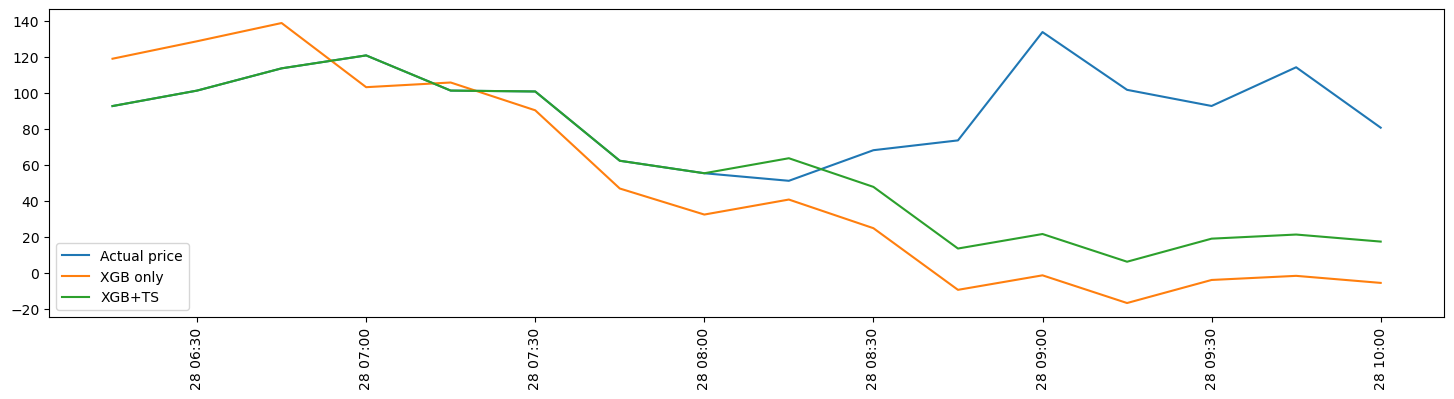

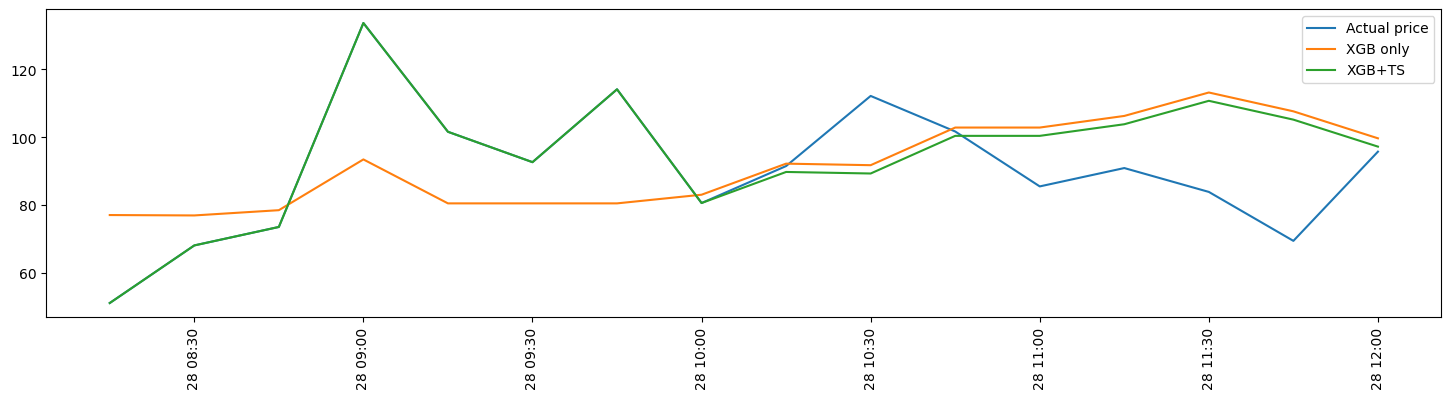

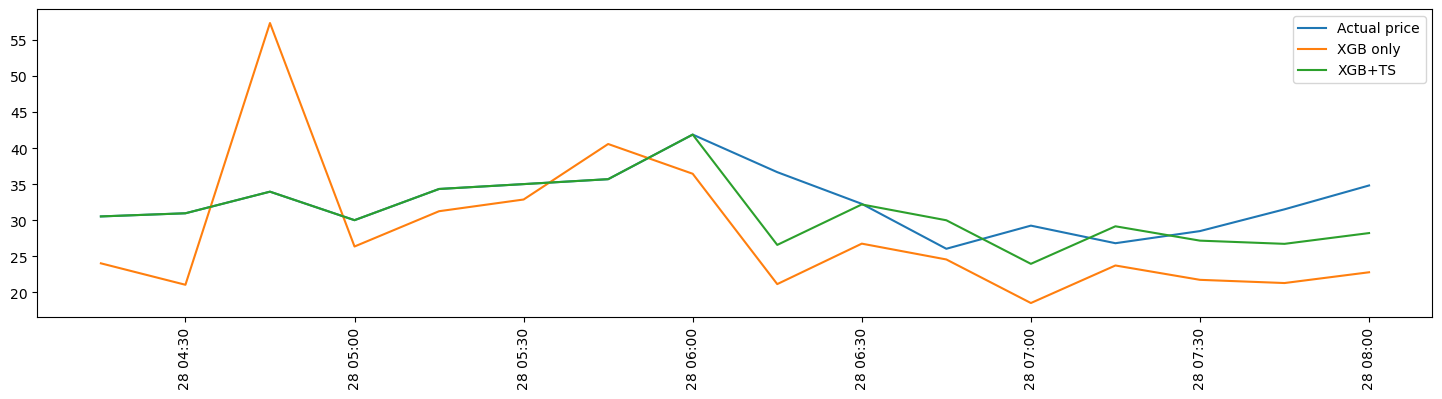

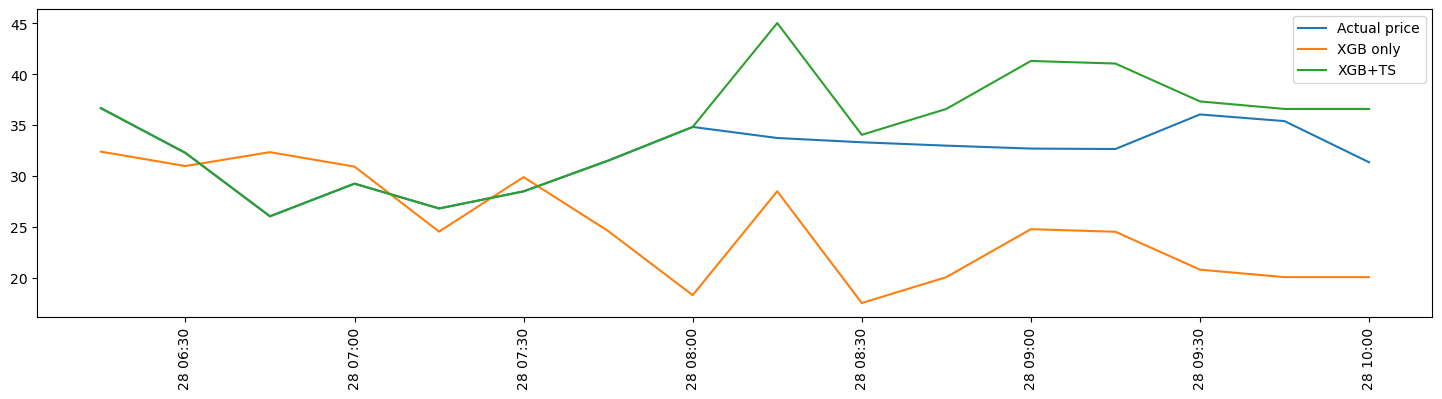

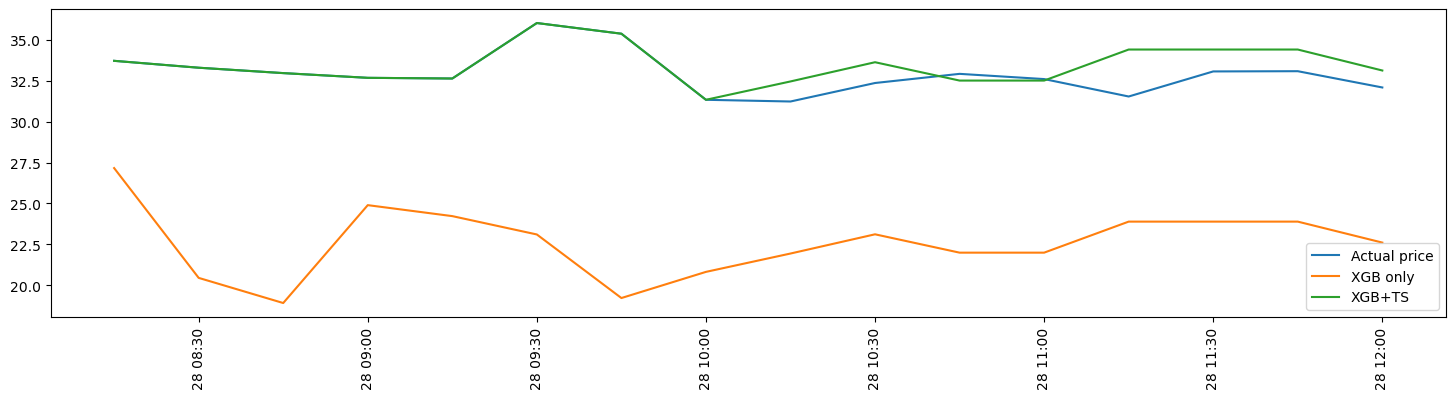

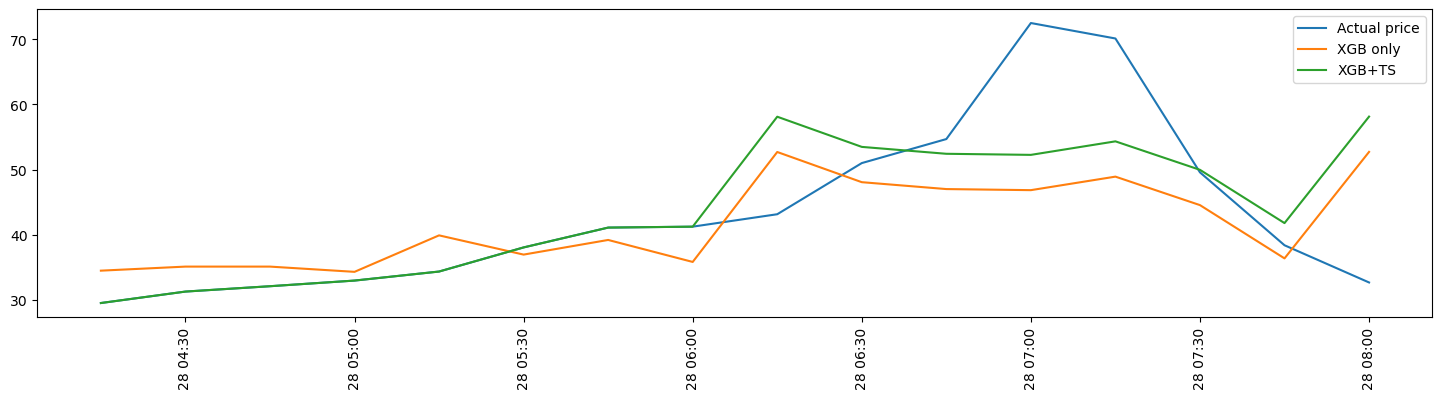

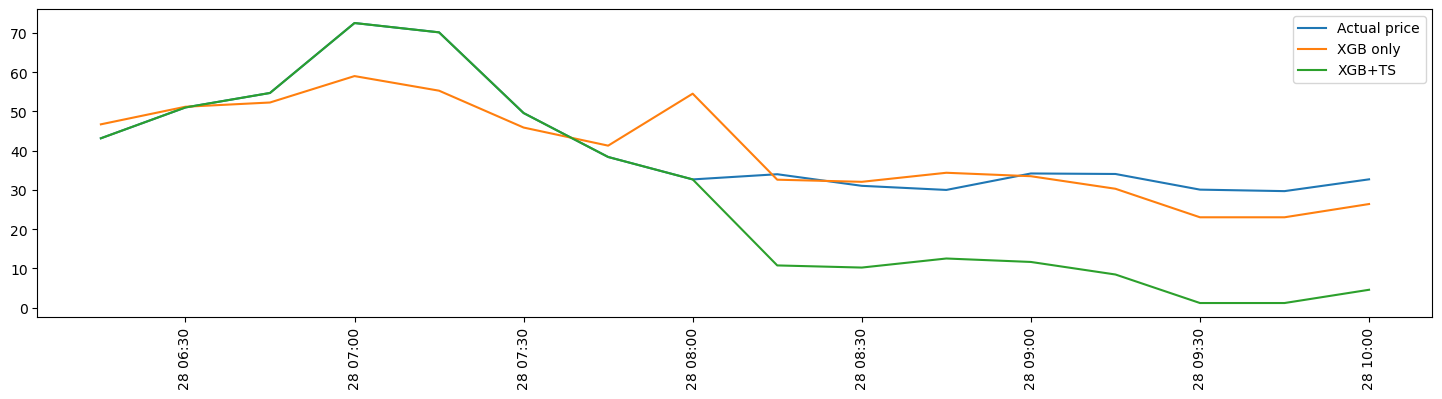

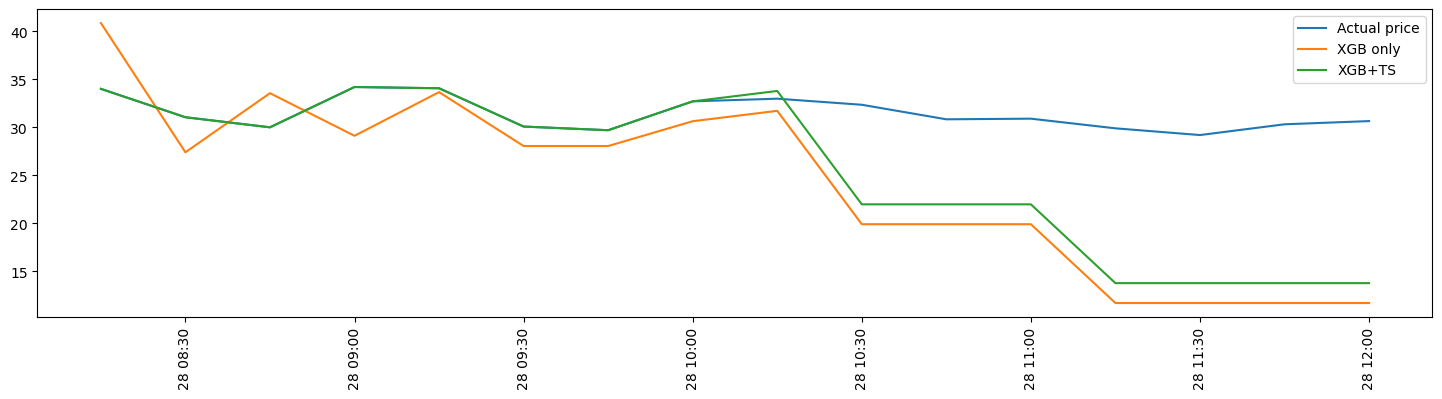

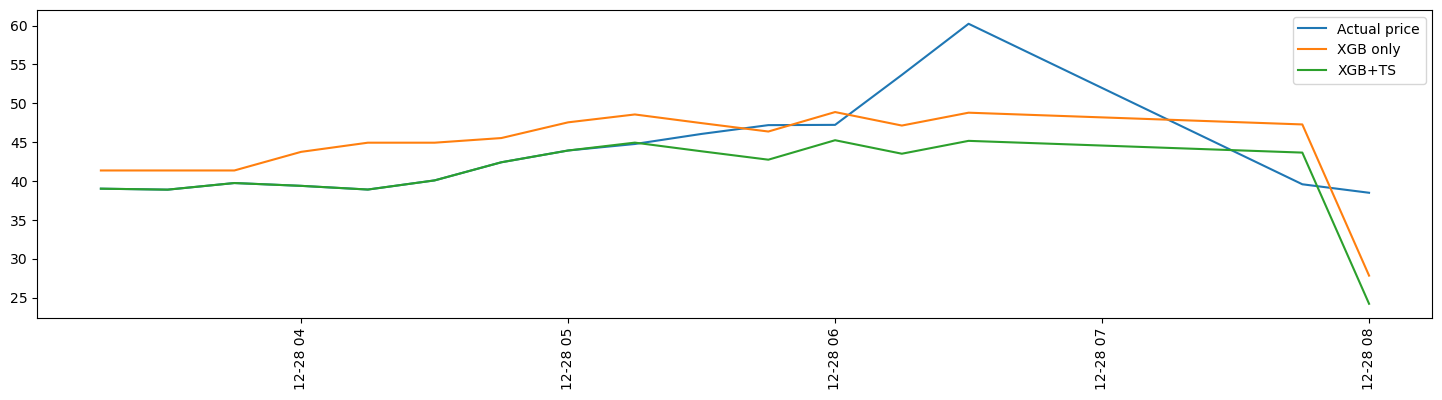

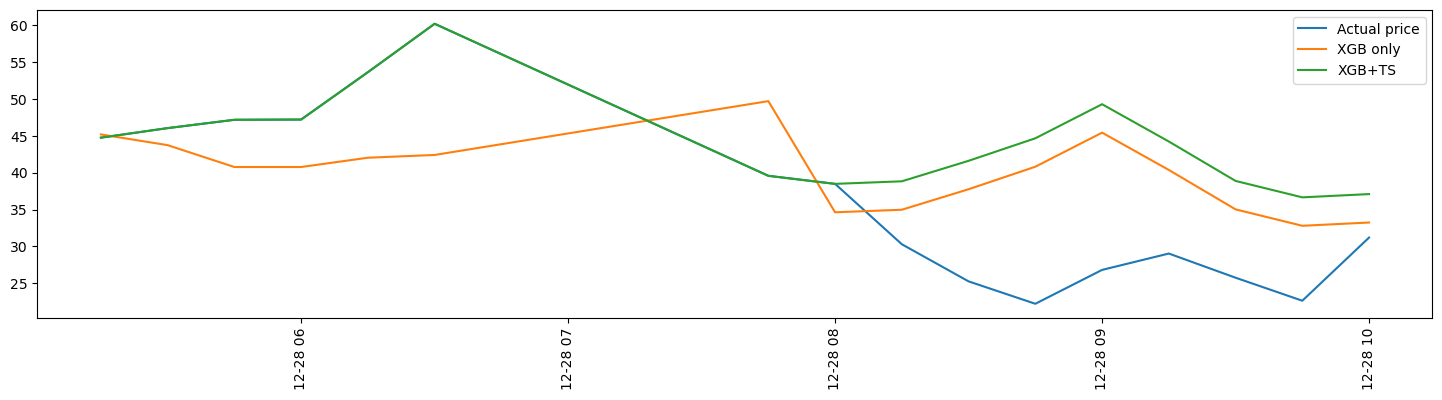

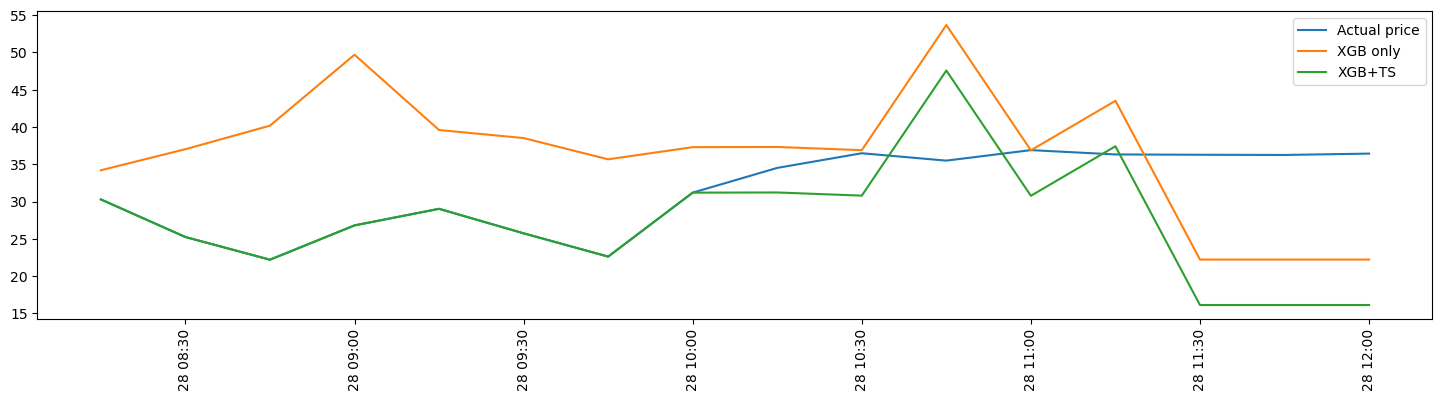

tod 0 done.


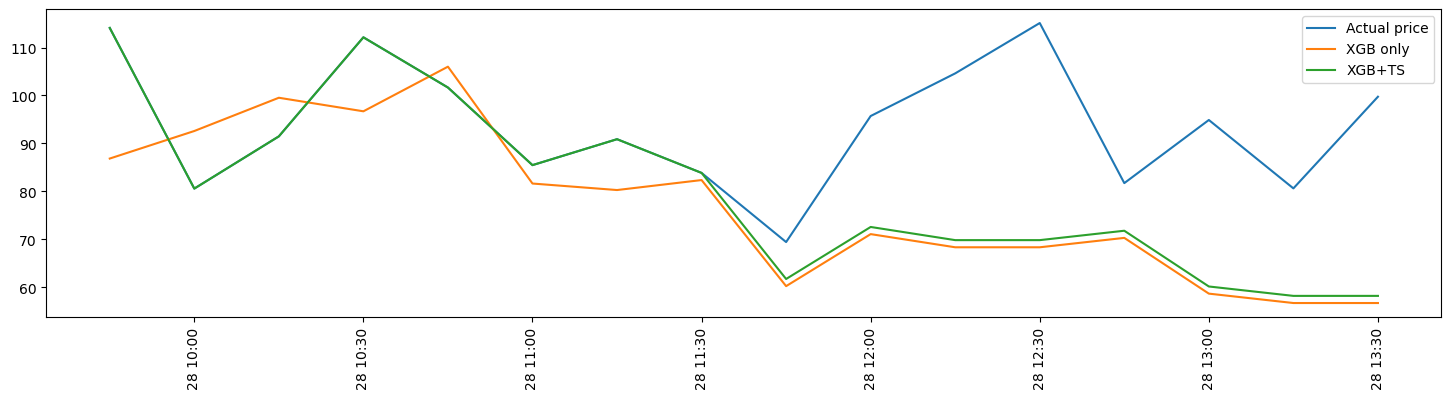

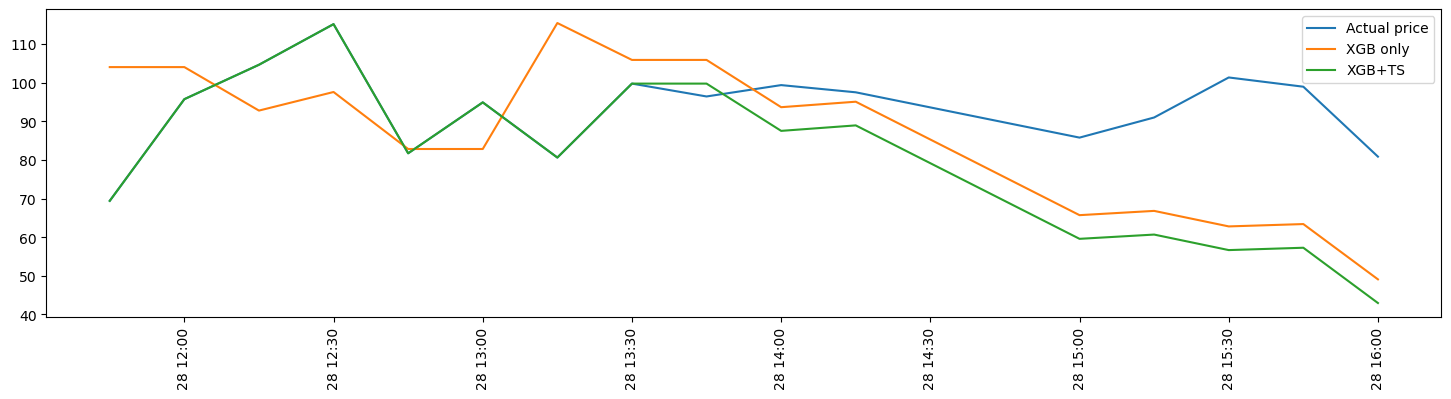

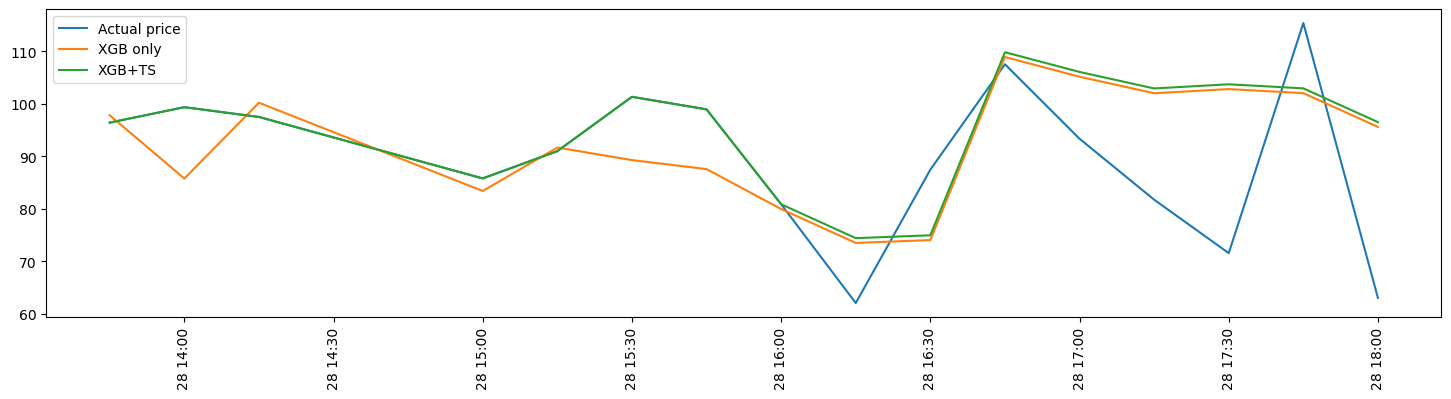

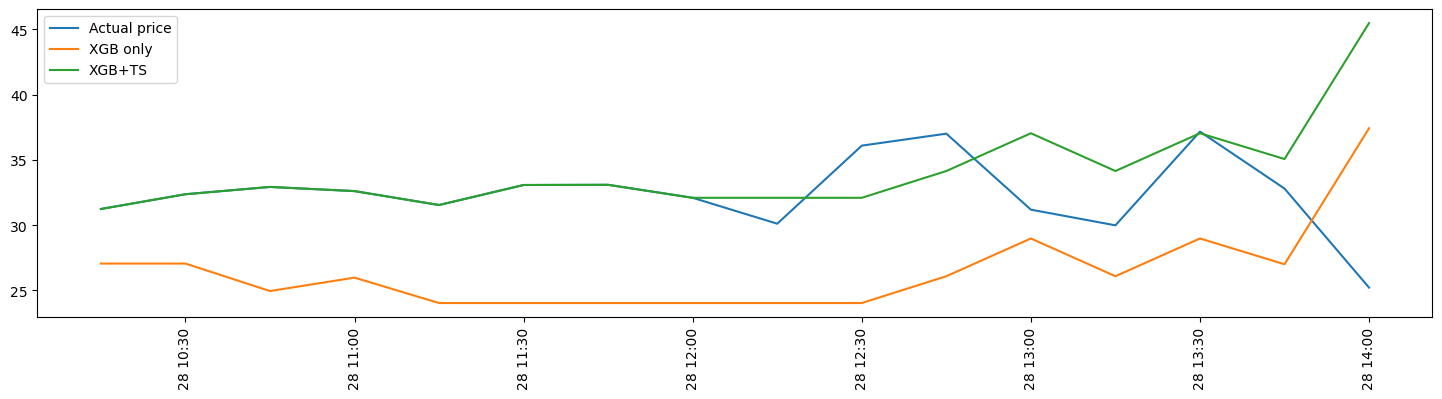

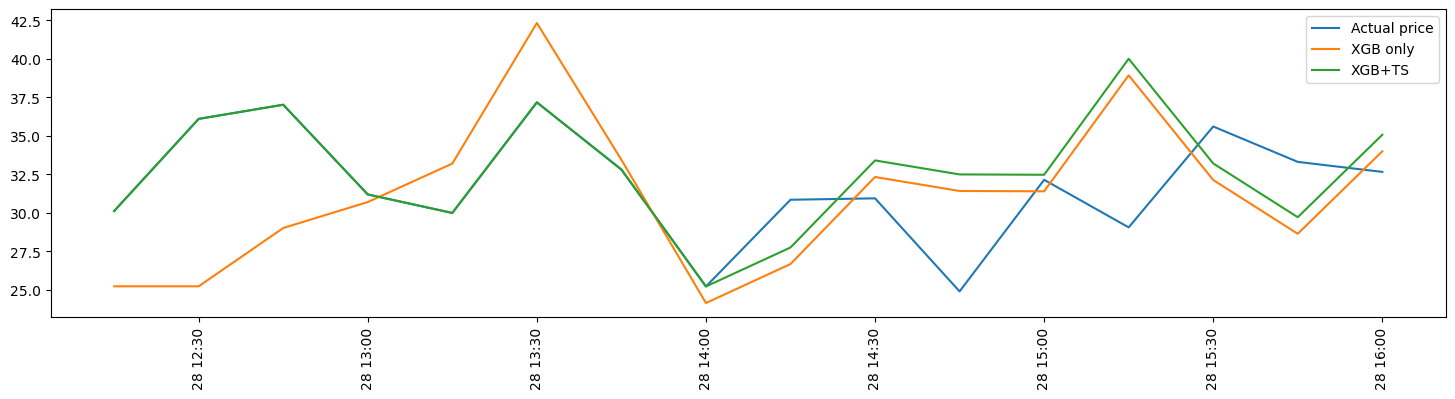

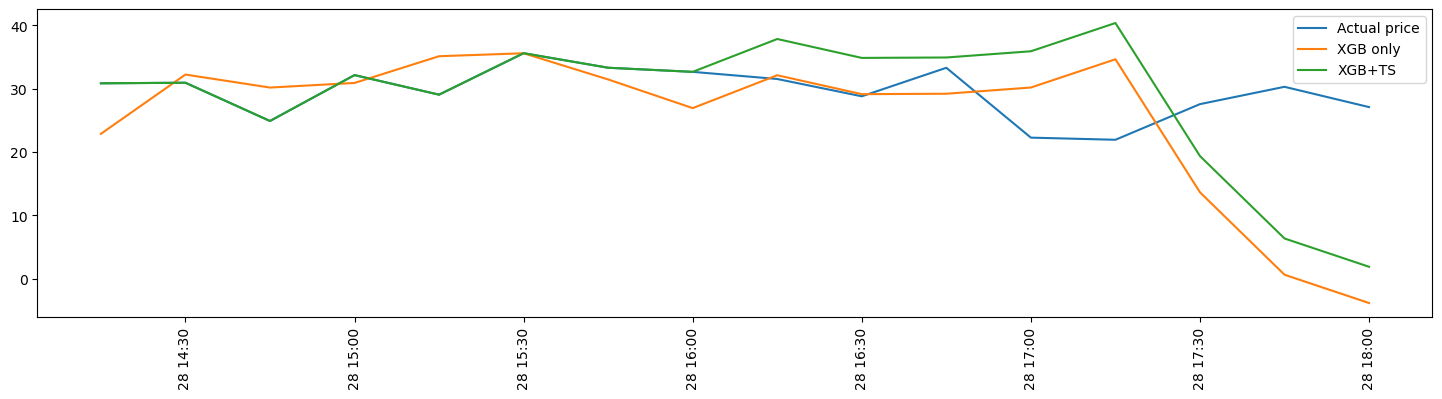

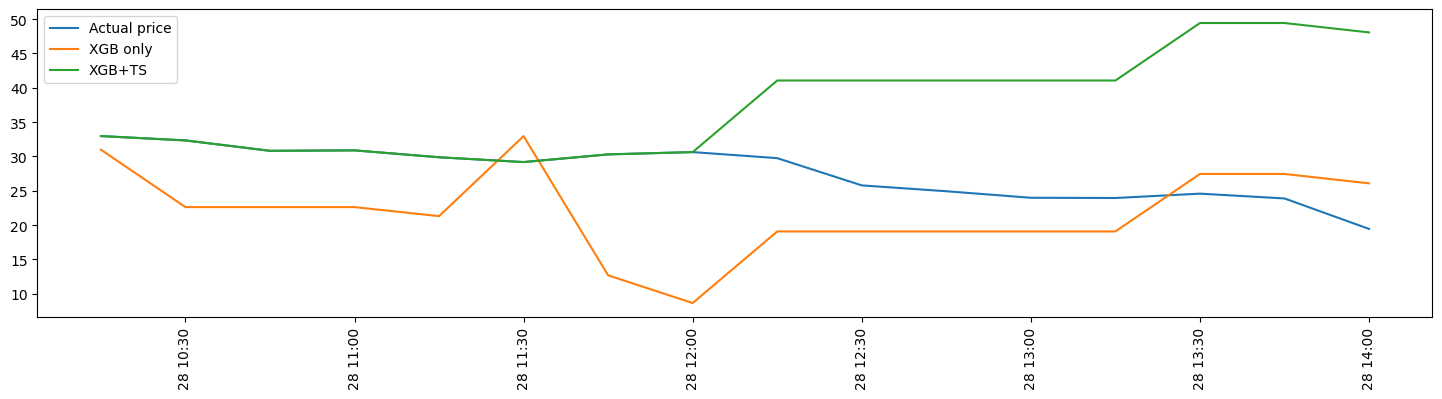

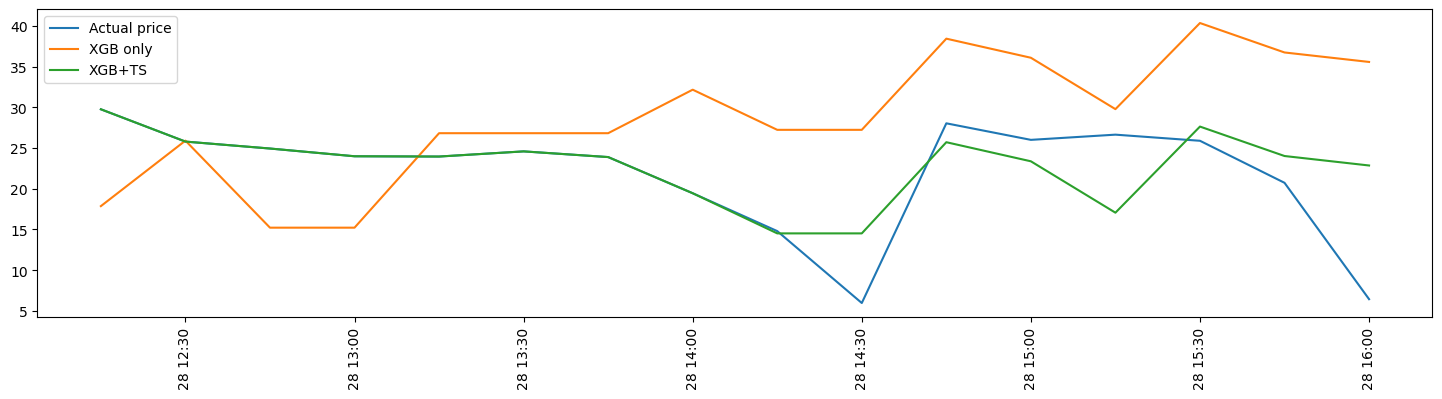

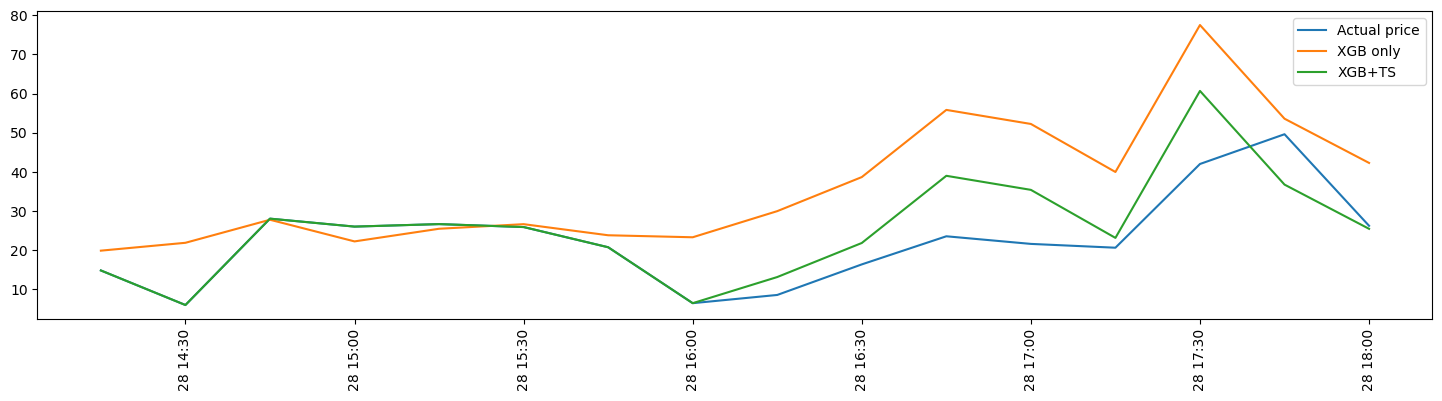

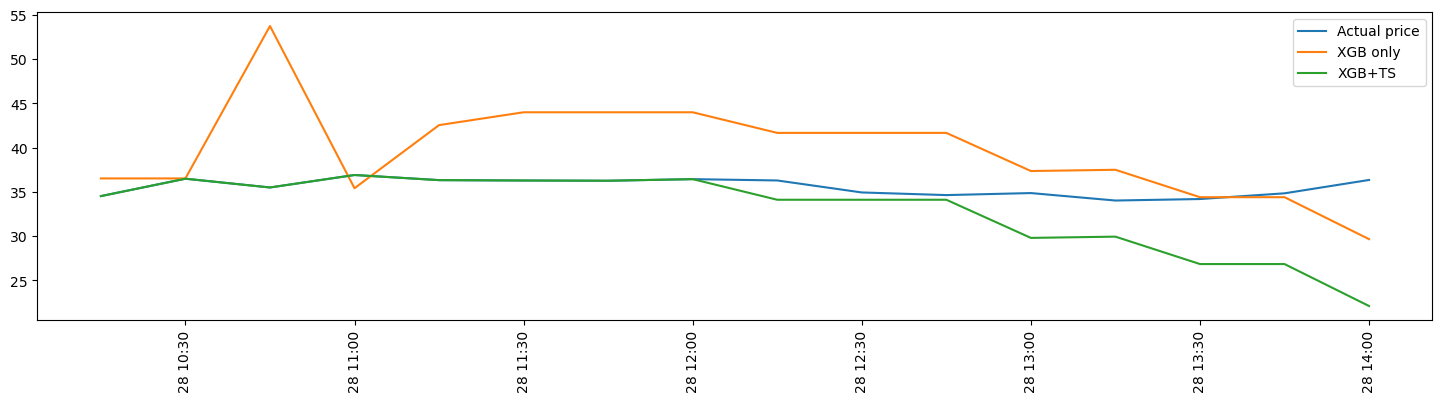

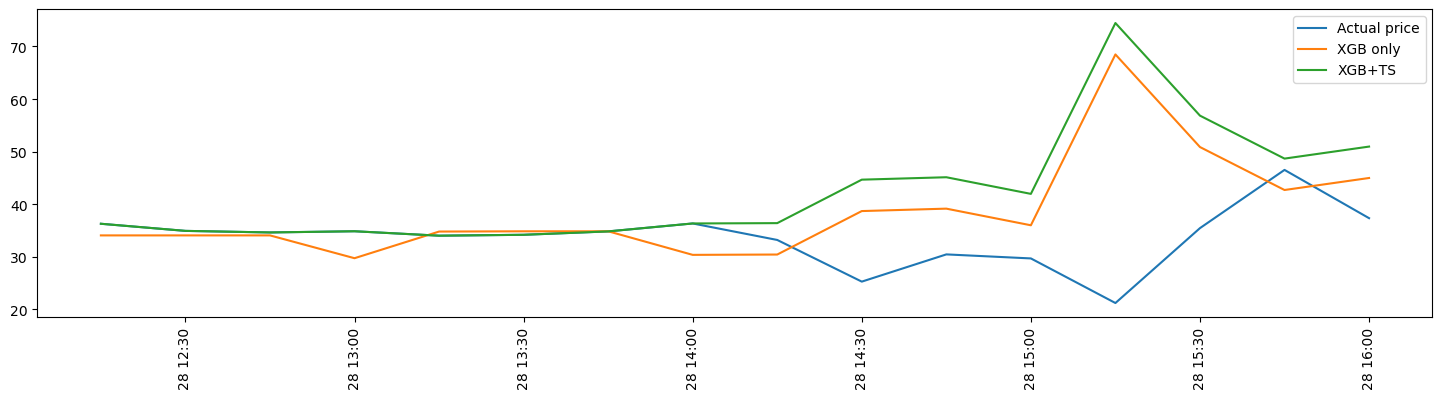

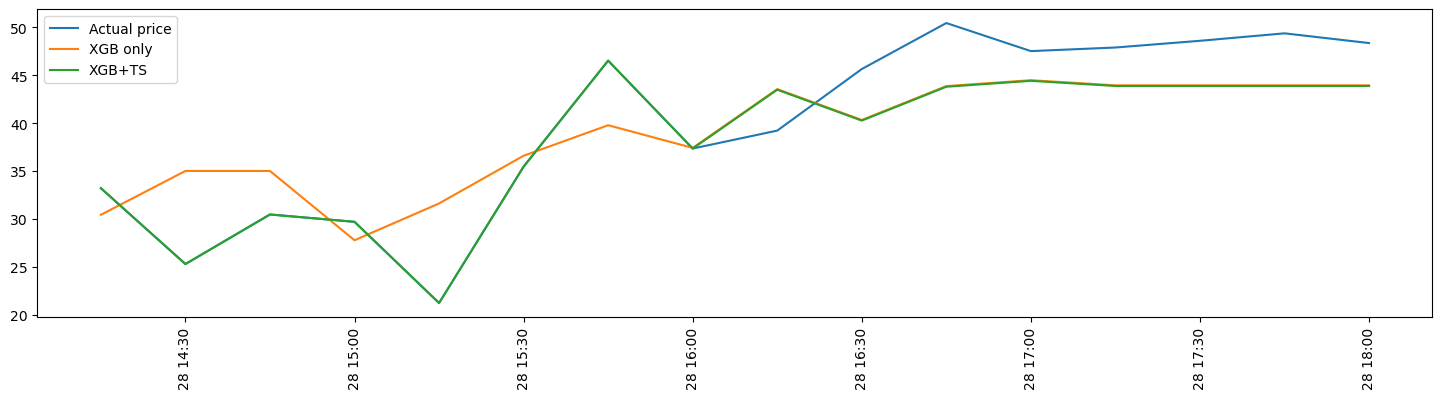

tod 1 done.
Validation error for 2023 = 479.4046389461378, baseline = 203.3395108579979


In [64]:
crossValidateFinal(2023, 3, 8, 120, (1,0,0), (0,1,0,96))

In [5]:
crossValidateFinal(2023, 3, 8, 20)

NameError: name 'TimeSeriesSplit' is not defined

In [ ]:
crossValidateFinal(2023, 3, 8, 40)

In [ ]:
crossValidateFinal(2023, 3, 8, 80)

In [ ]:
crossValidateFinal(2023, 3, 8, 300)